In [1]:
# Import modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score

import warnings

warnings.filterwarnings(
    "ignore", category=DeprecationWarning
)  # to avoid deprecation warnings

In [2]:
# Lecture des fichiers
print("Loading dataset...")
dataset = pd.read_csv("D:/Profils/NLefort/Desktop/JEDHA/PROJETS/05.ML_supervise/Walmart_Store_sales.csv")
print("...Done.")

Loading dataset...
...Done.


# Analyse descriptive

In [3]:
# 1. INFORMATIONS GENERALES
print("\n INFORMATIONS GENERALES")
print("-"*40)

print("Nombre de lignes : {}".format(dataset.shape[0]))
print("Nombre de colonnes : {}".format(dataset.shape[1]))
print("Nombre de magasins : {}".format(dataset['Store'].nunique()))

# Date : conversion de la colonne Date en format datetime
dataset['Date'] = pd.to_datetime(dataset['Date'], errors='coerce', dayfirst=True)
#  Afficher la plage des dates avec les heures
print("Période couverte: {} - {}".format(dataset['Date'].min(), dataset['Date'].max()))

print("Aperçu du dataset : ")
display(dataset.head())

print("Types de données/colonnes : ")
display(dataset.dtypes)



 INFORMATIONS GENERALES
----------------------------------------
Nombre de lignes : 150
Nombre de colonnes : 8
Nombre de magasins : 20
Période couverte: 2010-02-05 00:00:00 - 2012-10-19 00:00:00
Aperçu du dataset : 


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,6.0,2011-02-18,1572117.54,NaN,59.61,3.045,214.777523,6.858
1,13.0,2011-03-25,1807545.43,0.0,42.38,3.435,128.616064,7.470
2,17.0,2012-07-27,NaN,0.0,NaN,NaN,130.719581,5.936
3,11.0,NaT,1244390.03,0.0,84.57,NaN,214.556497,7.346
4,6.0,2010-05-28,1644470.66,0.0,78.89,2.759,212.412888,7.092


Types de données/colonnes : 


Store                  float64
Date            datetime64[ns]
Weekly_Sales           float64
Holiday_Flag           float64
Temperature            float64
Fuel_Price             float64
CPI                    float64
Unemployment           float64
dtype: object

In [4]:
# VALEURS MANQUANTES
print("\n VALEURS MANQUANTES")
print("-"*40)

print("Nombre de valeurs manquantes par colonne :")
missing_values = dataset.isnull().sum()
missing_values_percentage = ((missing_values / dataset.shape[0]) * 100).round(2)
missing_df = pd.DataFrame({
    "Valeurs manquantes": missing_values,
    "Pourcentage": missing_values_percentage
})
display(missing_df[missing_df["Valeurs manquantes"] > 0])



 VALEURS MANQUANTES
----------------------------------------
Nombre de valeurs manquantes par colonne :


,Valeurs manquantes,Pourcentage
Date,18,12.00
Weekly_Sales,14,9.33
Holiday_Flag,12,8.00
Temperature,18,12.00
Fuel_Price,14,9.33
CPI,12,8.00
Unemployment,15,10.00


In [5]:
# Conversion Fahrenheit -> Celsius
dataset['Temperature_C'] = (dataset['Temperature'] - 32) * 5/9
dataset['Temperature_C'] = dataset['Temperature_C'].round(2)

# Convertir Date en année / semaine / jour de semaine
dataset['Year'] = dataset['Date'].dt.year
dataset['Month'] = dataset['Date'].dt.month
dataset['Day'] = dataset['Date'].dt.day
dataset['Weekday'] = dataset['Date'].dt.weekday # 0 = Lundi, 6 = Dimanche

# Convertir Store en int
dataset['Store'] = dataset['Store'].astype(int)

print("Types de données/colonnes : ")
display(dataset.dtypes)


Types de données/colonnes : 


Store                     int64
Date             datetime64[ns]
Weekly_Sales            float64
Holiday_Flag            float64
Temperature             float64
Fuel_Price              float64
CPI                     float64
Unemployment            float64
Temperature_C           float64
Year                    float64
Month                   float64
Day                     float64
Weekday                 float64
dtype: object

In [6]:
# 2. STATISTIQUES DESCRIPTIVES

# Statistiques descriptives globales
print("Statistiques descriptives globales :")
display(dataset.describe(include="all").round(2))


Statistiques descriptives globales :


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Temperature_C,Year,Month,Day,Weekday
count,150.00,132,136.00,138.00,132.00,136.00,138.00,135.00,132.00,132.00,132.00,132.00,132.0
mean,9.87,2011-05-07 09:05:27.272727296,1249535.83,0.08,61.40,3.32,179.90,7.60,16.33,2010.86,6.39,16.52,4.0
min,1.00,2010-02-05 00:00:00,268929.03,0.00,18.79,2.51,126.11,5.14,-7.34,2010.00,1.00,1.00,4.0
25%,4.00,2010-08-16 12:00:00,605075.72,0.00,45.59,2.85,131.97,6.60,7.55,2010.00,4.00,10.00,4.0
50%,9.00,2011-05-09 12:00:00,1261423.86,0.00,62.98,3.45,197.91,7.47,17.22,2011.00,6.00,17.00,4.0
75%,15.75,2012-01-14 18:00:00,1806386.20,0.00,76.34,3.71,214.93,8.15,24.63,2012.00,9.00,24.00,4.0
max,20.00,2012-10-19 00:00:00,2771397.17,1.00,91.65,4.19,226.97,14.31,33.14,2012.00,12.00,31.00,4.0
std,6.23,NaN,647463.04,0.27,18.38,0.48,40.27,1.58,10.21,0.81,3.21,8.31,0.0


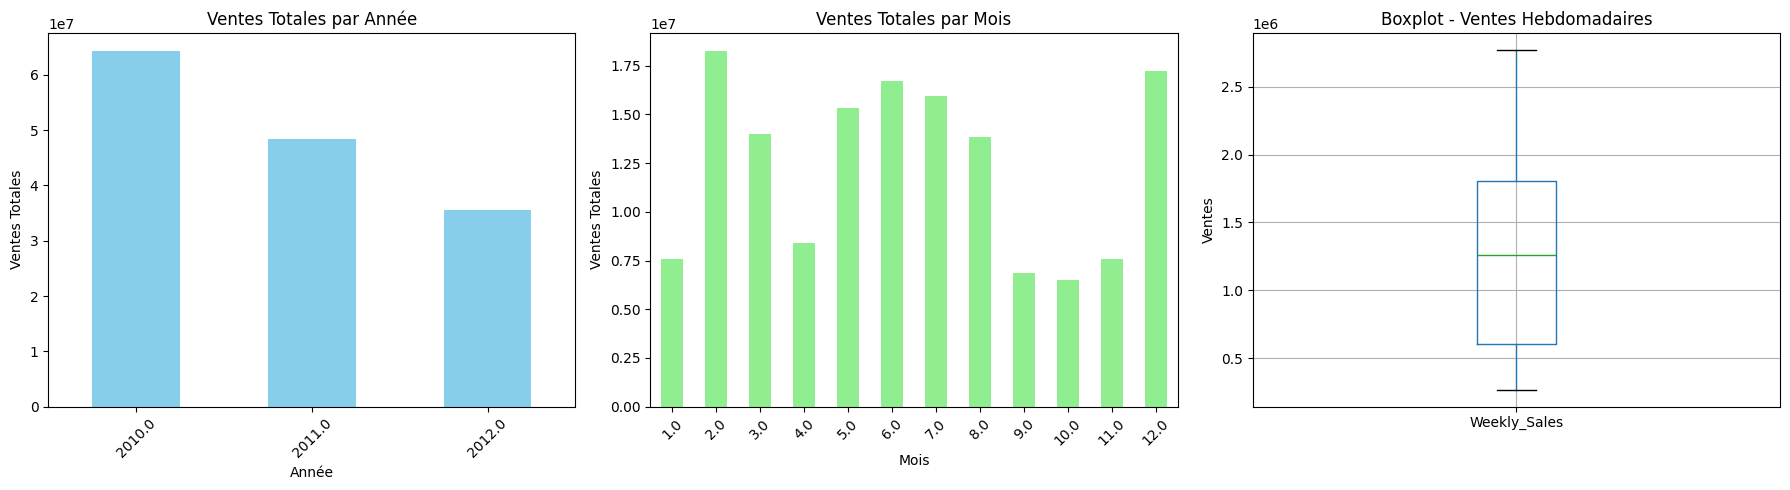

In [7]:
# Création d'une figure avec 3 sous-graphes sur une ligne
fig, axes = plt.subplots(1, 3, figsize=(18,5))  # 1 ligne, 3 colonnes

# Ventes Totales par Année
dataset.groupby('Year')['Weekly_Sales'].sum().plot(kind='bar', color='skyblue', ax=axes[0])
axes[0].set_title('Ventes Totales par Année')
axes[0].set_xlabel('Année')
axes[0].set_ylabel('Ventes Totales')
axes[0].tick_params(axis='x', rotation=45)

# Ventes Totales par Mois
dataset.groupby('Month')['Weekly_Sales'].sum().plot(kind='bar', color='lightgreen', ax=axes[1])
axes[1].set_title('Ventes Totales par Mois')
axes[1].set_xlabel('Mois')
axes[1].set_ylabel('Ventes Totales')
axes[1].tick_params(axis='x', rotation=45)

# Boxplot - Ventes Hebdomadaires
dataset.boxplot(column='Weekly_Sales', ax=axes[2])
axes[2].set_title('Boxplot - Ventes Hebdomadaires')
axes[2].set_ylabel('Ventes')

# Ajustement pour que les éléments ne se chevauchent pas
plt.tight_layout()
plt.show()


Nombre de magasins ayant au moins un jour férié : 8
Pourcentage de magasins concernés : 40.00%


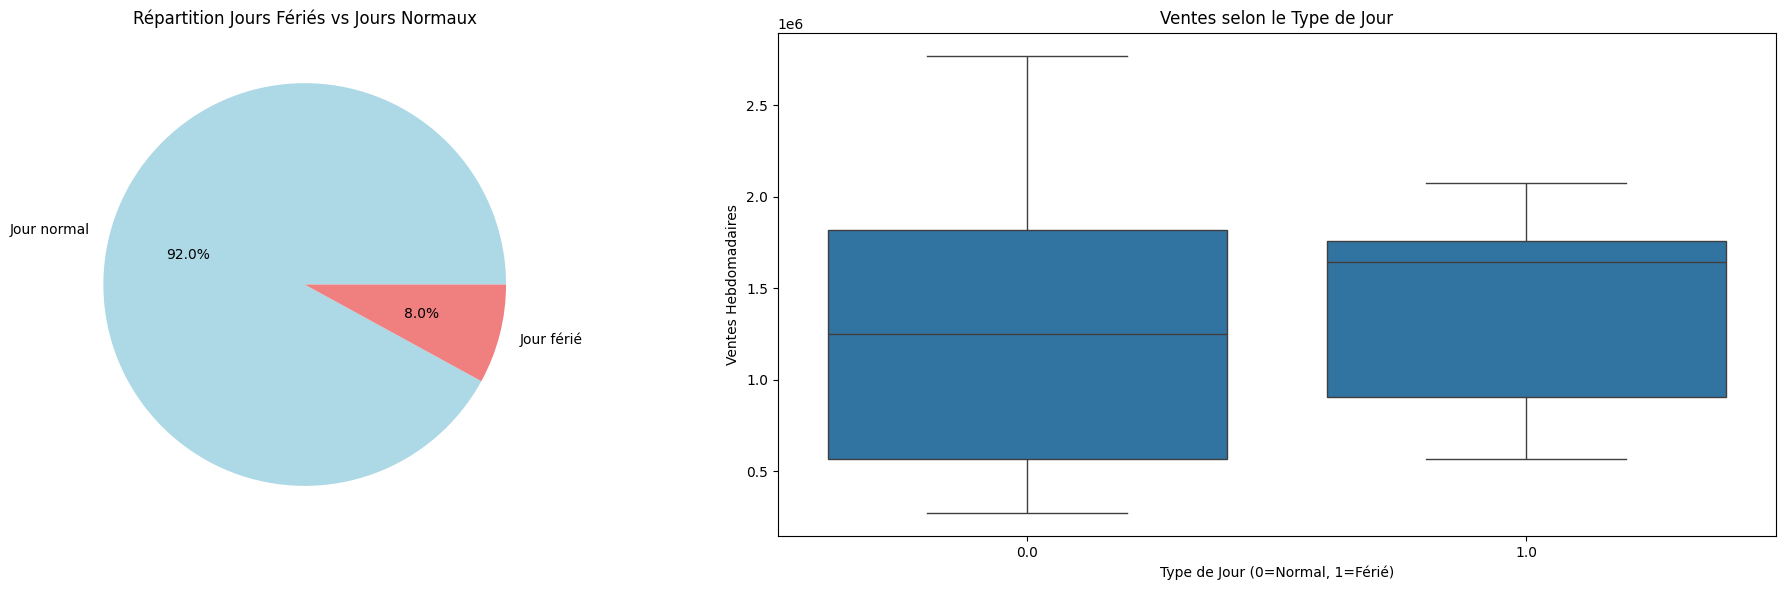

In [8]:
# Création de la figure avec 3 sous-graphes
fig, axes = plt.subplots(1, 2, figsize=(20,6))  # 1 ligne, 3 colonnes

# Nombre total de magasins
total_stores = dataset['Store'].nunique()
# Nombre de magasins avec au moins un jour férié
stores_with_holiday = dataset[dataset['Holiday_Flag'] == 1]['Store'].nunique()
# Pourcentage
percent_with_holiday = (stores_with_holiday / total_stores) * 100

print(f"Nombre de magasins ayant au moins un jour férié : {stores_with_holiday}")
print(f"Pourcentage de magasins concernés : {percent_with_holiday:.2f}%")

# Répartition Jours Fériés vs Jours Normaux (pie chart)
holiday_counts = dataset['Holiday_Flag'].value_counts()
axes[0].pie(holiday_counts.values, labels=['Jour normal', 'Jour férié'], autopct='%1.1f%%',
            colors=['lightblue', 'lightcoral'])
axes[0].set_title('Répartition Jours Fériés vs Jours Normaux')

# Ventes selon le type de jour (boxplot)
sns.boxplot(data=dataset, x='Holiday_Flag', y='Weekly_Sales', ax=axes[1])
axes[1].set_title('Ventes selon le Type de Jour')
axes[1].set_xlabel('Type de Jour (0=Normal, 1=Férié)')
axes[1].set_ylabel('Ventes Hebdomadaires')


# Ajustement des espaces
plt.tight_layout()
plt.show()

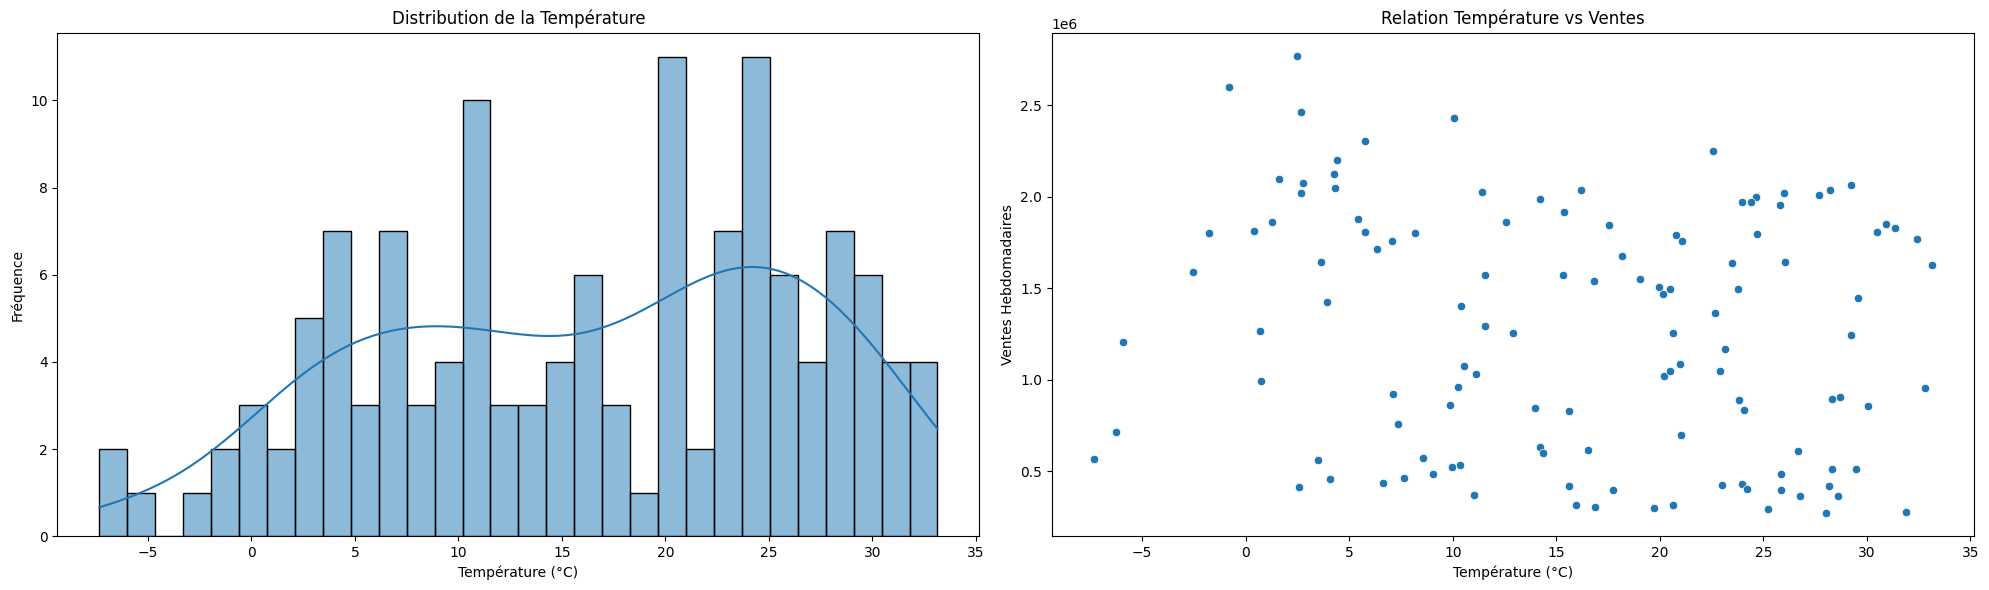

In [9]:
# Création de la figure avec 2 sous-graphes
fig, axes = plt.subplots(1, 2, figsize=(20,6))  # 1 ligne, 2 colonnes

# Distribution de la température
sns.histplot(data=dataset, x='Temperature_C', bins=30, kde=True, ax=axes[0])
axes[0].set_title('Distribution de la Température')
axes[0].set_xlabel('Température (°C)')
axes[0].set_ylabel('Fréquence')

# Températures vs ventes hebdomadaires
sns.scatterplot(data=dataset, x='Temperature_C', y='Weekly_Sales', ax=axes[1])
axes[1].set_title('Relation Température vs Ventes')
axes[1].set_xlabel('Température (°C)')
axes[1].set_ylabel('Ventes Hebdomadaires')

# Ajustement des espaces
plt.tight_layout()
plt.show()

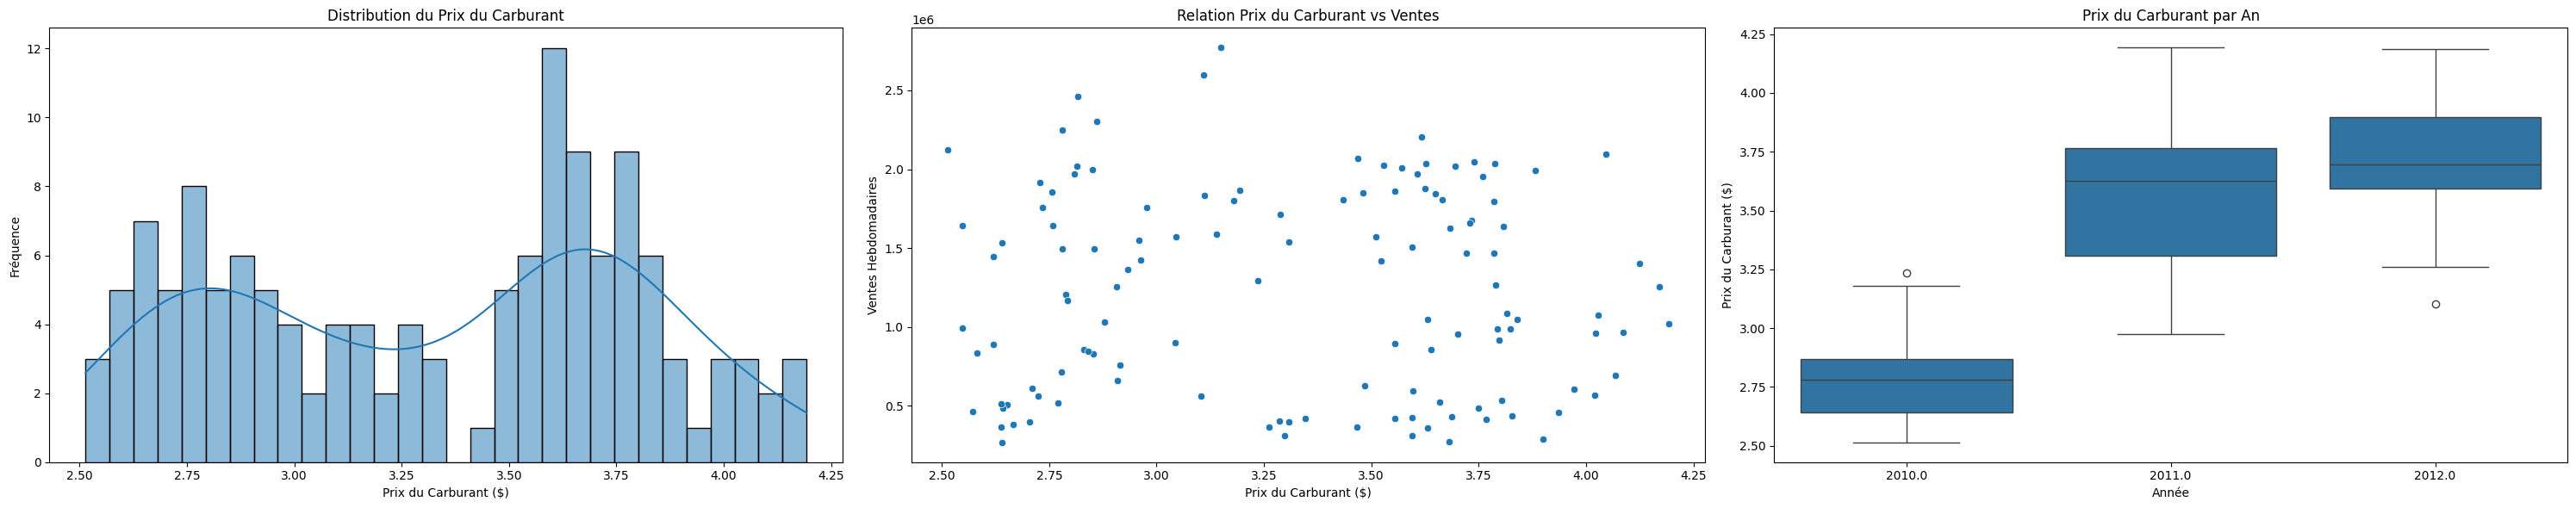

In [10]:
# Création de la figure avec 3 sous-graphes
fig, axes = plt.subplots(1, 3, figsize=(30,6))  # 1 ligne, 3 colonnes

# Distribution Prix du Carburant
sns.histplot(data=dataset, x='Fuel_Price', bins=30, kde=True, ax=axes[0])
axes[0].set_title('Distribution du Prix du Carburant')
axes[0].set_xlabel('Prix du Carburant ($)')
axes[0].set_ylabel('Fréquence')

# Prix du Carburant vs ventes hebdomadaires
sns.scatterplot(data=dataset, x='Fuel_Price', y='Weekly_Sales', ax=axes[1])
axes[1].set_title('Relation Prix du Carburant vs Ventes')
axes[1].set_xlabel('Prix du Carburant ($)')
axes[1].set_ylabel('Ventes Hebdomadaires')

# Prix du carburant vs mois
sns.boxplot(data=dataset, x='Year', y='Fuel_Price', ax=axes[2])
axes[2].set_title('Prix du Carburant par An')
axes[2].set_xlabel('Année')
axes[2].set_ylabel('Prix du Carburant ($)')

# Ajustement des espaces
plt.tight_layout()
plt.show()

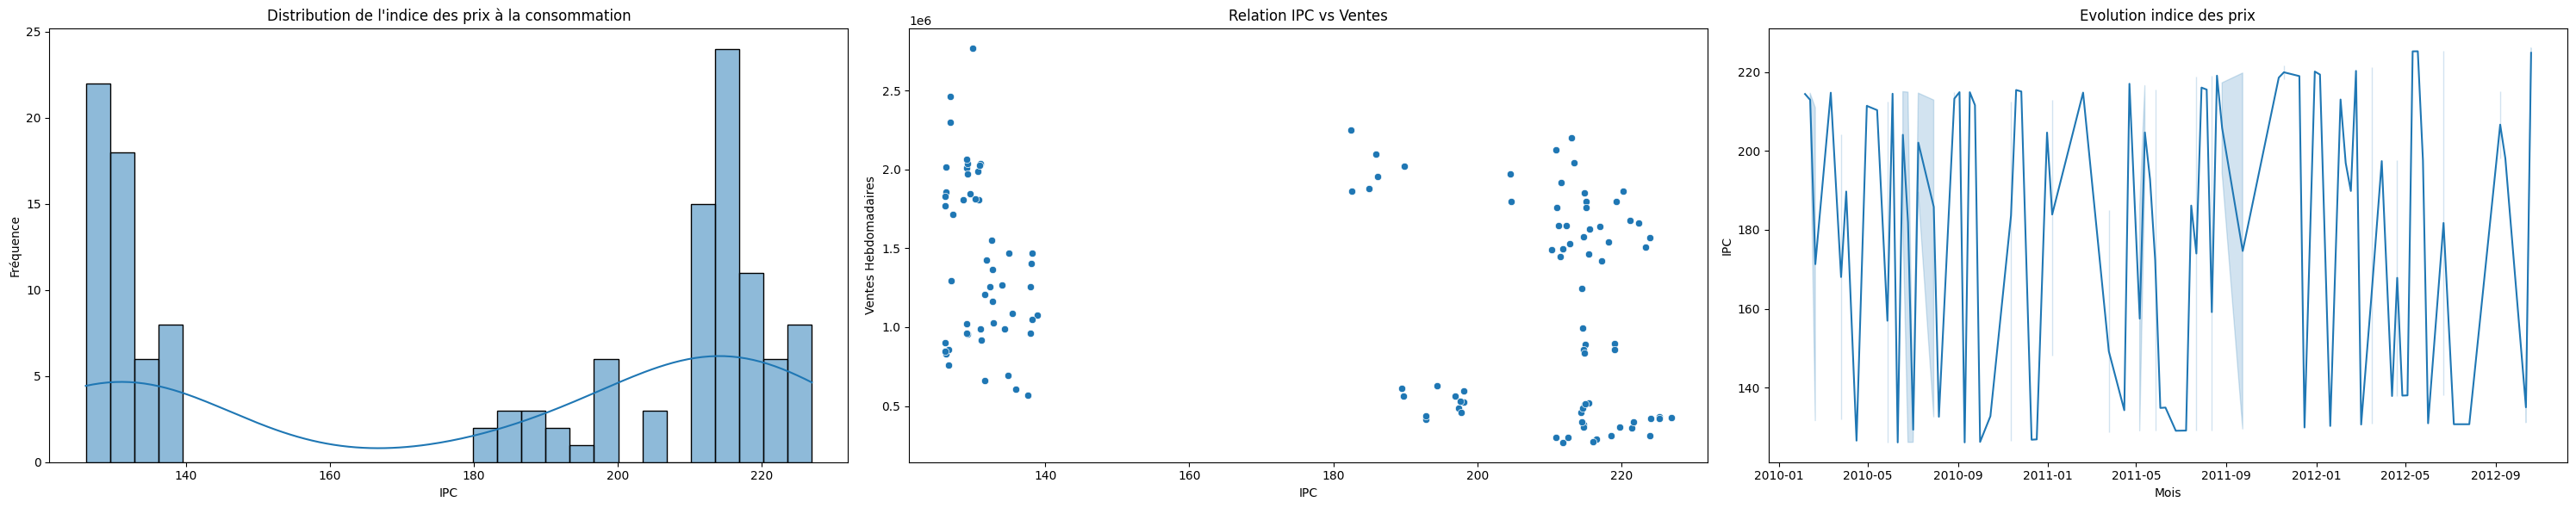

In [11]:
# Création de la figure avec 3 sous-graphes
fig, axes = plt.subplots(1, 3, figsize=(30,6))  # 1 ligne, 3 colonnes

# Distribution IPC
sns.histplot(data=dataset, x='CPI', bins=30, kde=True, ax=axes[0])
axes[0].set_title('Distribution de l\'indice des prix à la consommation')
axes[0].set_xlabel('IPC')
axes[0].set_ylabel('Fréquence')

# IPC vs ventes hebdomadaires
sns.scatterplot(data=dataset, x='CPI', y='Weekly_Sales', ax=axes[1])
axes[1].set_title('Relation IPC vs Ventes')
axes[1].set_xlabel('IPC')
axes[1].set_ylabel('Ventes Hebdomadaires')

# IPC vs date
sns.lineplot(data=dataset, x='Date', y='CPI', ax=axes[2])
axes[2].set_title('Evolution indice des prix')
axes[2].set_xlabel('Mois')
axes[2].set_ylabel('IPC')

# Ajustement des espaces
plt.tight_layout()
plt.show()

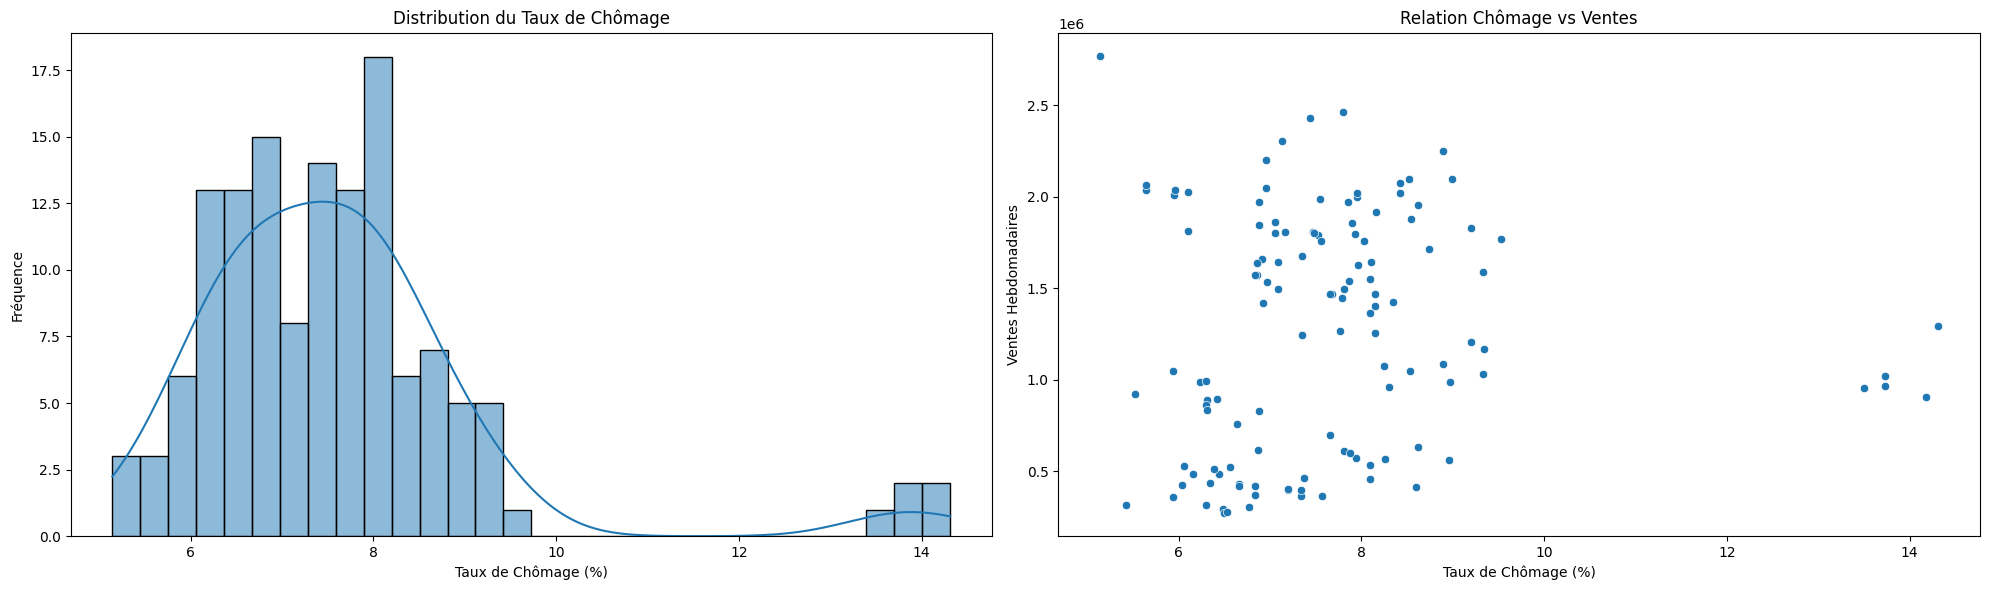

In [12]:
# Création de la figure avec 2 sous-graphes
fig, axes = plt.subplots(1, 2, figsize=(20,6))  # 1 ligne, 2 colonnes

# CHÔMAGE
sns.histplot(data=dataset, x='Unemployment', bins=30, kde=True, ax=axes[0])
axes[0].set_title('Distribution du Taux de Chômage')
axes[0].set_xlabel('Taux de Chômage (%)')
axes[0].set_ylabel('Fréquence')

# CORRÉLATION CHÔMAGE-VENTES
sns.scatterplot(data=dataset, x='Unemployment', y='Weekly_Sales', ax=axes[1])
axes[1].set_title('Relation Chômage vs Ventes')
axes[1].set_xlabel('Taux de Chômage (%)')
axes[1].set_ylabel('Ventes Hebdomadaires')

# Ajustement des espaces
plt.tight_layout()
plt.show()

In [13]:
# Top 5 magasins par ventes moyennes
top_stores = dataset.groupby('Store')['Weekly_Sales'].mean().nlargest(5)
bottom_stores = dataset.groupby('Store')['Weekly_Sales'].mean().nsmallest(5)
print("Top 5 magasins (ventes moyennes):")
print(top_stores)
print("\nBottom 5 magasins (ventes moyennes):")
print(bottom_stores)


Top 5 magasins (ventes moyennes):
Store
4     2.173759e+06
14    2.092878e+06
13    1.997235e+06
20    1.962384e+06
2     1.943034e+06
Name: Weekly_Sales, dtype: float64

Bottom 5 magasins (ventes moyennes):
Store
5     302499.683750
3     403054.945833
9     506887.400000
16    515317.772500
7     559129.952500
Name: Weekly_Sales, dtype: float64


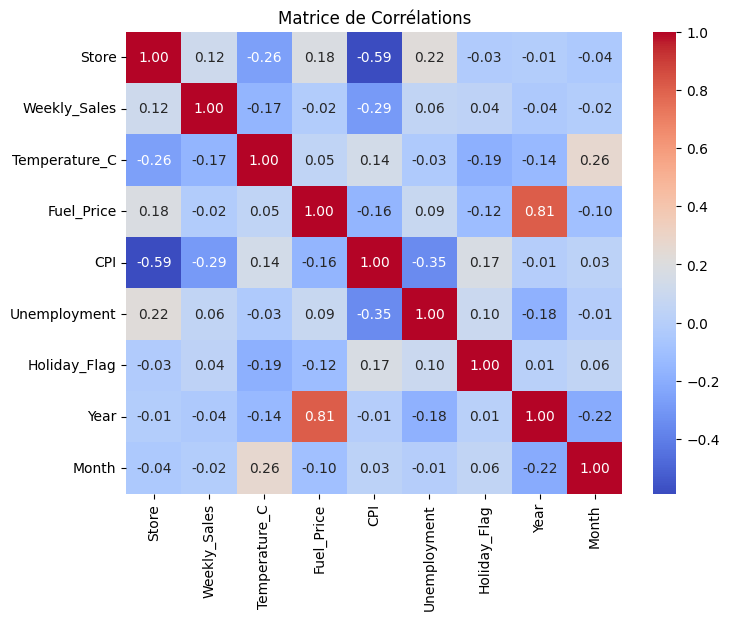


           FIN DE L'ANALYSE DESCRIPTIVE


In [14]:
# Matrice de Corrélations
plt.figure(figsize=(8,6))
sns.heatmap(dataset[['Store','Weekly_Sales','Temperature_C','Fuel_Price','CPI','Unemployment', 'Holiday_Flag', 'Year', 'Month']].corr(),
            annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matrice de Corrélations")
plt.show()

print("\n" + "="*60)
print("           FIN DE L'ANALYSE DESCRIPTIVE")
print("="*60)

## Synthèse

# Prétraitement

In [15]:
useless_cols = ["Date", "Temperature"]  # Assurez-vous que ces colonnes existent
print("Dropping useless columns...")
dataset_clean_useless_cols = dataset.drop(useless_cols, axis=1, errors='ignore')  # errors='ignore' pour éviter les erreurs
print("...Done.")
print(dataset_clean_useless_cols.head())


Dropping useless columns...
...Done.
   Store  Weekly_Sales  Holiday_Flag  Fuel_Price         CPI  Unemployment  \
0      6    1572117.54           NaN       3.045  214.777523         6.858   
1     13    1807545.43           0.0       3.435  128.616064         7.470   
2     17           NaN           0.0         NaN  130.719581         5.936   
3     11    1244390.03           0.0         NaN  214.556497         7.346   
4      6    1644470.66           0.0       2.759  212.412888         7.092   

   Temperature_C    Year  Month   Day  Weekday  
0          15.34  2011.0    2.0  18.0      4.0  
1           5.77  2011.0    3.0  25.0      4.0  
2            NaN  2012.0    7.0  27.0      4.0  
3          29.21     NaN    NaN   NaN      NaN  
4          26.05  2010.0    5.0  28.0      4.0  


In [16]:
# Vérification des valeurs manquantes avant nettoyage
missing_values = dataset_clean_useless_cols.isnull().sum()
print("Valeurs manquantes par colonne :")
print(missing_values[missing_values > 0])
print(f"Total de lignes : {dataset_clean_useless_cols.shape[0]}")

Valeurs manquantes par colonne :
Weekly_Sales     14
Holiday_Flag     12
Fuel_Price       14
CPI              12
Unemployment     15
Temperature_C    18
Year             18
Month            18
Day              18
Weekday          18
dtype: int64
Total de lignes : 150


In [22]:
# Supprimer les lignes où la cible est manquante
dataset_clean_useless_cols = dataset_clean_useless_cols.dropna(subset=['Weekly_Sales'])

# Supprimer les valeurs aberrantes sur les colonnes numériques
for col in ['Temperature_C', 'Fuel_Price', 'CPI', 'Unemployment']:
    mean = dataset_clean_useless_cols[col].mean()
    std = dataset_clean_useless_cols[col].std()
    dataset_clean_outliers = dataset_clean_useless_cols[(dataset_clean_useless_cols[col] >= mean - 3*std) & (dataset_clean_useless_cols[col] <= mean + 3*std)]

print(f"Nombre de lignes restantes : {dataset_clean_outliers.shape[0]}")

Nombre de lignes restantes : 90


In [ ]:
# 3. Nettoyage des valeurs aberrantes pour Weekly_Sales
print("\nSupprimer valeurs manquantes/négatives dans les ventes hebdomadaires...")
initial_rows = dataset_clean_useless_cols.shape[0]
# Garder seulement les valeurs positives ET non nulles
to_keep = (dataset_clean_useless_cols["Weekly_Sales"] > 0) & (dataset_clean_useless_cols["Weekly_Sales"].notna())
dataset_clean_useless_cols = dataset_clean_useless_cols.loc[to_keep, :]
print(f"Lignes supprimées : {initial_rows - dataset_clean_useless_cols.shape[0]}")
print(f"Nombre de lignes restantes : {dataset_clean_useless_cols.shape[0]}")

# 4. Suppression des valeurs extrêmes (outliers) - CORRECTION IMPORTANTE
print("\nSupprimer valeurs extrêmes...")
# Colonnes numériques pour l'analyse des outliers
numeric_cols_for_outliers = ["Temperature_C", "Fuel_Price", "CPI", "Unemployment"]

# CORRECTION : utiliser dataset_clean_useless_cols au lieu de dataset
mean_vals = dataset_clean_useless_cols[numeric_cols_for_outliers].mean()
std_vals = dataset_clean_useless_cols[numeric_cols_for_outliers].std()

# Bornes d'acceptation (règle des 3 sigma)
lower = mean_vals - 3 * std_vals
upper = mean_vals + 3 * std_vals

print("Bornes d'acceptation (mean ± 3σ) :")
for col in numeric_cols_for_outliers:
    print(f"{col}: [{lower[col]:.2f}, {upper[col]:.2f}]")

# Condition : toutes les colonnes doivent être dans les bornes OU être NaN
conditions = []
for col in numeric_cols_for_outliers:
    condition = ((dataset_clean_useless_cols[col] >= lower[col]) & 
                (dataset_clean_useless_cols[col] <= upper[col])) | dataset_clean_useless_cols[col].isna()
    conditions.append(condition)

# Toutes les conditions doivent être vraies
to_keep = pd.concat(conditions, axis=1).all(axis=1)
initial_rows = dataset_clean_useless_cols.shape[0]
dataset_clean_outliers = dataset_clean_useless_cols.loc[to_keep, :]

print(f"Lignes supprimées (outliers) : {initial_rows - dataset_clean_outliers.shape[0]}")
print(f"Nombre de lignes restantes : {dataset_clean_outliers.shape[0]}")


Supprimer valeurs manquantes/négatives dans les ventes hebdomadaires...
Lignes supprimées : 14
Nombre de lignes restantes : 136

Supprimer valeurs extrêmes...
Bornes d'acceptation (mean ± 3σ) :
Temperature_C: [-14.83, 46.89]
Fuel_Price: [1.88, 4.76]
CPI: [57.36, 298.82]
Unemployment: [2.81, 12.52]
Lignes supprimées (outliers) : 5
Nombre de lignes restantes : 131


In [ ]:
missing_after_cleaning = dataset_clean_outliers.isnull().sum()
print("Valeurs manquantes par colonne :")
print(missing_after_cleaning[missing_after_cleaning > 0])

Valeurs manquantes par colonne :
Holiday_Flag     11
Fuel_Price       12
CPI              11
Unemployment     14
Temperature_C    14
Year             18
Month            18
Day              18
Weekday          18
dtype: int64


In [ ]:
# 6. Séparation target/features
target_name = "Weekly_Sales"
print(f"\nSeparating labels from features...")
Y = dataset_clean_outliers.loc[:, target_name]
X = dataset_clean_outliers.drop(target_name, axis=1)
print("...Done.")

# 7. Division train/test
print("Dividing into train and test sets...")
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=0)
print(f"Train set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# 8. FONCTION DE CONVERSION AMÉLIORÉE
def safe_float_to_int(X):
    """Convertit les float en int en gérant les NaN"""
    X_copy = X.copy()
    
    # Identifier les colonnes qui doivent être converties en int
    int_columns = ['Year', 'Month', 'Day', 'Weekday', 'Holiday_Flag', 'Store']
    
    for col in int_columns:
        if col in X_copy.columns:
            # Convertir seulement les valeurs non-NaN
            mask = X_copy[col].notna()
            if mask.any():
                X_copy.loc[mask, col] = X_copy.loc[mask, col].astype(int)
    
    return X_copy

# 9. PIPELINES AMÉLIORÉS
# Colonnes numériques continues
numeric_continuous = ["Fuel_Price", "CPI", "Unemployment", "Temperature_C"]

# Colonnes numériques discrètes (à convertir en int)
numeric_discrete = ["Year", "Month", "Day", "Weekday"]

# Colonnes catégorielles
categorical_cols = ["Holiday_Flag", "Store"]

# Pipeline pour les variables numériques continues
numeric_continuous_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline pour les variables numériques discrètes
numeric_discrete_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # ou 'median'
    ('float_to_int', FunctionTransformer(lambda x: x.astype(int), validate=False)),
    ('scaler', StandardScaler())
])

# Pipeline pour les variables catégorielles
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('float_to_int', FunctionTransformer(lambda x: x.astype(int), validate=False)),
    ('encoder', OneHotEncoder(drop='first'))

])

# 10. PREPROCESSEUR COMPLET
preprocessor = ColumnTransformer(
    transformers=[
        ('num_continuous', numeric_continuous_transformer, numeric_continuous),
        ('num_discrete', numeric_discrete_transformer, numeric_discrete),
        ('cat', categorical_transformer, categorical_cols)
    ],

)



Separating labels from features...
...Done.
Dividing into train and test sets...
Train set: 104 samples
Test set: 27 samples


In [ ]:

# 11. APPLICATION DU PREPROCESSING
print("\n=== PREPROCESSING ===")
print("Performing preprocessing on train set...")
print("Colonnes dans X_train:", X_train.columns.tolist())
print("Types de données avant preprocessing:")
print(X_train.dtypes)

# Vérifier les valeurs manquantes avant preprocessing
print("\nValeurs manquantes dans X_train avant preprocessing:")
print(X_train.isnull().sum())

# Fit + transform sur le train set
X_train_transformed = preprocessor.fit_transform(X_train)
print("Train set preprocessed.")
print(f"Shape après transformation: {X_train_transformed.shape}")

# Transform sur le test set
print("Performing preprocessing on test set...")
X_test_transformed = preprocessor.transform(X_test)
print("Test set preprocessed.")
print(f"Shape après transformation: {X_test_transformed.shape}")


print("\n=== PREPROCESSING TERMINÉ ===")
print("Les données sont prêtes pour l'entraînement du modèle!")

# Juste pour voir le nombre de features
print(f"Nombre de features: {X_train_transformed.shape[1]}")
print(f"Premières valeurs: {X_train_transformed[0][:10]}")


=== PREPROCESSING ===
Performing preprocessing on train set...
Colonnes dans X_train: ['Store', 'Holiday_Flag', 'Fuel_Price', 'CPI', 'Unemployment', 'Temperature_C', 'Year', 'Month', 'Day', 'Weekday']
Types de données avant preprocessing:
Store              int64
Holiday_Flag     float64
Fuel_Price       float64
CPI              float64
Unemployment     float64
Temperature_C    float64
Year             float64
Month            float64
Day              float64
Weekday          float64
dtype: object

Valeurs manquantes dans X_train avant preprocessing:
Store             0
Holiday_Flag      8
Fuel_Price       10
CPI               8
Unemployment      8
Temperature_C    12
Year             10
Month            10
Day              10
Weekday          10
dtype: int64
Train set preprocessed.
Shape après transformation: (104, 27)
Performing preprocessing on test set...
Test set preprocessed.
Shape après transformation: (27, 27)

=== PREPROCESSING TERMINÉ ===
Les données sont prêtes pour l'entra

In [ ]:
# 2. Créer le pipeline complet avec scaling final
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler()),  # Scaling global après encodage
    ('regressor', LinearRegression())
])

pipeline.fit(X_train, Y_train)

# Récupérer le scaler depuis le pipeline
scaler = pipeline.named_steps['scaler']
# Vérifier la moyenne et l'écart-type des données après scaling
X_train_scaled = scaler.transform(preprocessor.transform(X_train))
print("Moyenne des features après scaling :", X_train_scaled.mean(axis=0))
print("Écart-type des features après scaling :", X_train_scaled.std(axis=0))


# --- Prédictions ---
Y_pred_train = pipeline.predict(X_train)
Y_pred_test = pipeline.predict(X_test)


# --- Évaluation ---
print("Train RMSE :", root_mean_squared_error(Y_train, Y_pred_train))
print("Train R2   :", r2_score(Y_train, Y_pred_train))
print("Test RMSE  :", root_mean_squared_error(Y_test, Y_pred_test))
print("Test R2    :", r2_score(Y_test, Y_pred_test))

Moyenne des features après scaling : [ 3.20256642e-17  2.98906199e-17  2.45530092e-17 -2.17007235e-17
  6.08487619e-17 -6.61863726e-17  3.09581420e-17  0.00000000e+00
 -4.27008856e-17  9.39419482e-17  1.06752214e-18  2.13504428e-17
  1.32372745e-16  1.49453099e-16 -7.47265497e-18 -4.10996024e-17
 -4.43021688e-17 -6.61863726e-17 -8.75368154e-17 -1.76141153e-16
 -3.52282306e-17 -1.32372745e-16 -8.05979215e-17 -1.15826152e-16
  8.11316826e-17  1.81478764e-17  1.38777878e-17]
Écart-type des features après scaling : [1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1.]
Train RMSE : 105547.28378256959
Train R2   : 0.9744242711552161
Test RMSE  : 161340.98501842056
Test R2    : 0.9314833321133507


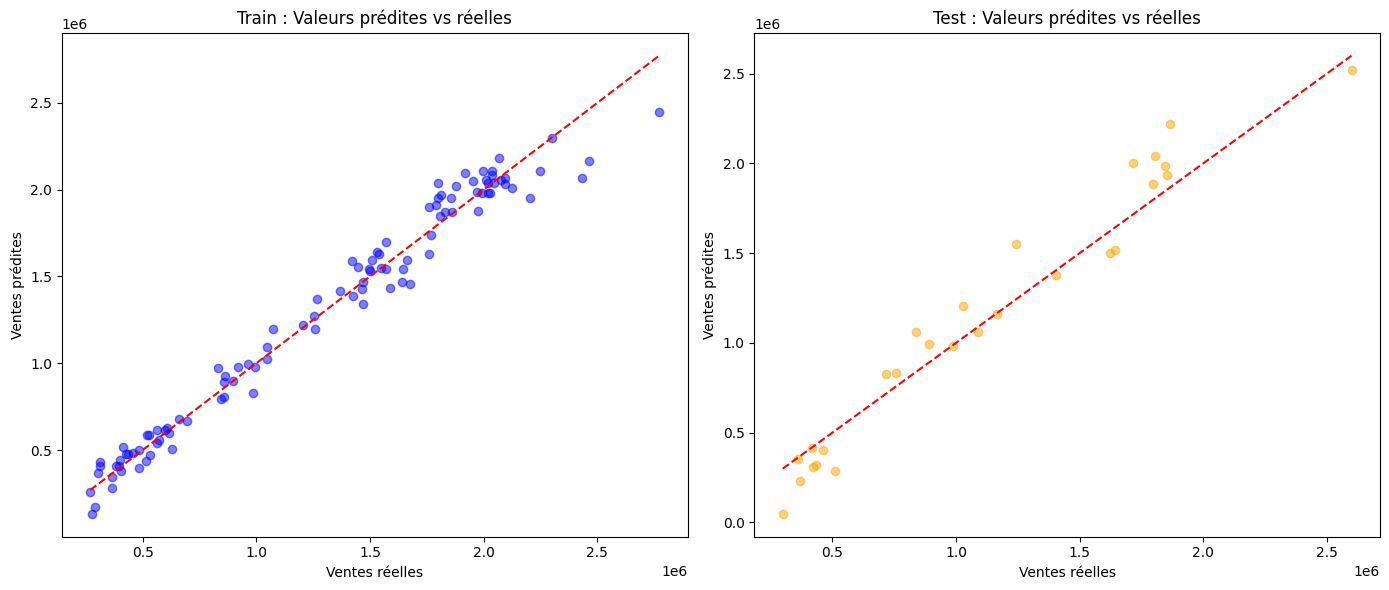

In [ ]:
plt.figure(figsize=(14,6))

# Graphique train
plt.subplot(1,2,1)
plt.scatter(Y_train, Y_pred_train, alpha=0.5, color='blue')
plt.plot([Y_train.min(), Y_train.max()], [Y_train.min(), Y_train.max()], 'r--')  # ligne y=x
plt.xlabel("Ventes réelles")
plt.ylabel("Ventes prédites")
plt.title("Train : Valeurs prédites vs réelles")

# Graphique test
plt.subplot(1,2,2)
plt.scatter(Y_test, Y_pred_test, alpha=0.5, color='orange')
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--')  # ligne y=x
plt.xlabel("Ventes réelles")
plt.ylabel("Ventes prédites")
plt.title("Test : Valeurs prédites vs réelles")

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

# Extraire le modèle final du pipeline
regressor = pipeline.named_steps['regressor']

# Extraire le préprocesseur
preprocessor = pipeline.named_steps['preprocessor']

# Récupérer les noms des colonnes après transformation
# 1. Numériques
num_features_transformed = numeric_features  # les numériques sont scalées mais gardent le même nom

# 2. Catégorielles encodées
cat_features_transformed = preprocessor.named_transformers_['cat'] \
                                      .named_steps['encoder'].get_feature_names_out(categorical_cols)

# Combiner toutes les colonnes
all_features = np.concatenate([num_features_transformed, cat_features_transformed])

# Récupérer les coefficients
coefficients = regressor.coef_

# Créer un DataFrame pour visualiser
coef_df = pd.DataFrame({
    'Feature': all_features,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', key=abs, ascending=False)  # tri par importance absolue

print(coef_df.head(30))  # top 30 features

           Feature   Coefficient
12         Store_5 -3.261304e+05
10         Store_3 -3.162614e+05
14         Store_7 -2.196171e+05
16         Store_9 -2.128288e+05
22        Store_16 -2.110621e+05
20        Store_14  1.836180e+05
19        Store_13  1.537625e+05
11         Store_4  1.524206e+05
23        Store_17 -1.515003e+05
15         Store_8 -1.433056e+05
21        Store_15 -1.228618e+05
17        Store_10  1.187747e+05
2     Unemployment -9.772170e+04
1              CPI  9.535227e+04
9          Store_2  9.424841e+04
26        Store_20  8.036809e+04
5            Month  6.565099e+04
0       Fuel_Price -4.271471e+04
3    Temperature_C -3.812035e+04
6              Day -3.443494e+04
25        Store_19  3.187894e+04
24        Store_18 -3.096094e+04
4             Year -1.936152e+04
8   Holiday_Flag_1 -1.261687e+04
13         Store_6 -4.472128e+03
18        Store_11  3.090562e+02
7          Weekday  1.564331e-10



=== EXEMPLE DE CORRECTION AVEC RIDGE ===
Entraînement du modèle Ridge avec CV...
# Décommentez les lignes suivantes pour tester Ridge:
# grid_search.fit(X_train, Y_train)
# best_ridge = grid_search.best_estimator_
# Y_pred_ridge = best_ridge.predict(X_test)
# print(f'Ridge RMSE: {np.sqrt(mean_squared_error(Y_test, Y_pred_ridge))}')

=== GRAPHIQUE RECOMMANDÉ ===
Pour visualiser les coefficients:


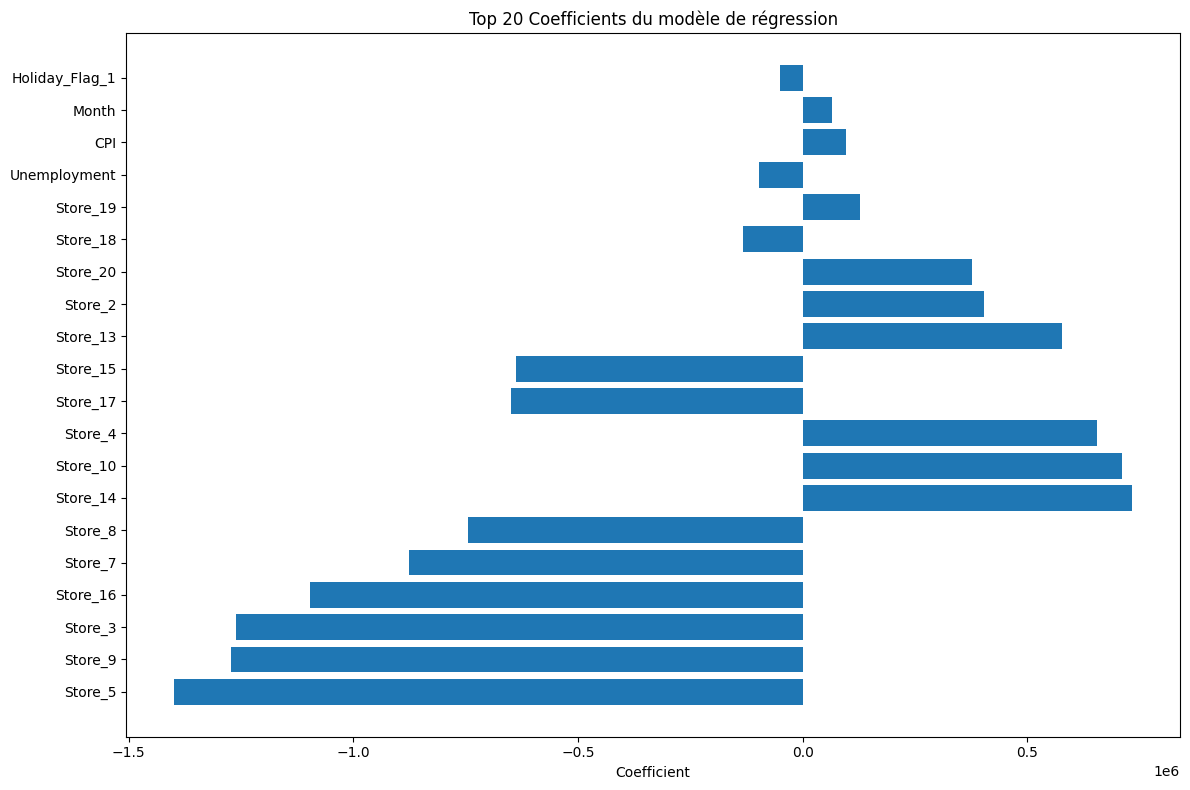

In [ ]:
# === CODE POUR RÉGRESSION RIDGE ===
print(f"\n=== EXEMPLE DE CORRECTION AVEC RIDGE ===")

from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# Modèle avec régularisation Ridge
ridge_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", Ridge())
])

# Recherche du meilleur alpha
param_grid = {'regressor__alpha': [0.1, 1, 10, 100, 1000]}
grid_search = GridSearchCV(ridge_model, param_grid, cv=5, 
                          scoring='neg_mean_squared_error', n_jobs=-1)

print("Entraînement du modèle Ridge avec CV...")
# grid_search.fit(X_train, Y_train)  # Décommentez pour exécuter
print("# Décommentez les lignes suivantes pour tester Ridge:")
print("# grid_search.fit(X_train, Y_train)")
print("# best_ridge = grid_search.best_estimator_")
print("# Y_pred_ridge = best_ridge.predict(X_test)")
print("# print(f'Ridge RMSE: {np.sqrt(mean_squared_error(Y_test, Y_pred_ridge))}')")

# === VISUALISATION DES COEFFICIENTS ===
print(f"\n=== GRAPHIQUE RECOMMANDÉ ===")
print("Pour visualiser les coefficients:")

plt.figure(figsize=(12, 8))
top_20 = coef_df.head(20)
plt.barh(range(len(top_20)), top_20['Coefficient'])
plt.yticks(range(len(top_20)), top_20['Feature'])
plt.xlabel('Coefficient')
plt.title('Top 20 Coefficients du modèle de régression')
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.linear_model import Ridge
from sklearn.metrics import root_mean_squared_error, r2_score
import numpy as np

# Option 1 : Scaler la target
Y_train_scaled = Y_train / 1_000_000  # ou np.log1p(Y_train)
Y_test_scaled = Y_test / 1_000_000

# Option 2 : Utiliser un modèle très régularisé
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler()),
    ('regressor', Ridge(alpha=1000))  # Augmente alpha
])

# Entraînement
pipeline.fit(X_train, Y_train_scaled)

# Coefficients
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()
coefficients = pipeline.named_steps['regressor'].coef_
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', key=abs, ascending=False)
print(coef_df.head(30))

# Prédictions (n'oublie pas de rescaler si tu as scalé la target)
Y_pred_train = pipeline.predict(X_train) * 1_000_000
Y_pred_test = pipeline.predict(X_test) * 1_000_000


AttributeError: Estimator float_to_int does not provide get_feature_names_out. Did you mean to call pipeline[:-1].get_feature_names_out()?